# Visualizzazione Avanzata: Estrazione Semantica e Topologica

Questo notebook serve a visualizzare passo-passo il funzionamento dello script `semantic_extractor.py`. 
Esploreremo come il **Co-Embedding Spettrale** riesca a separare oggetti complessi integrando l'informazione semantica (Cross-Attention) e quella fisica (Campo Vettoriale di Velocità).

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import T5Tokenizer

# Aggiungiamo il path per importare il modulo appena creato
sys.path.append(os.path.abspath("../"))
from src.flowstitch.semantic_extractor import extract_subtokens_attention, build_co_embedding_laplacian

from scipy.sparse.linalg import eigsh
import warnings
warnings.filterwarnings('ignore')

## 1. Caricamento Dati Reali
Utilizziamo la scena multi-oggetto per testare la capacità di scomposizione.

In [2]:
dataset_path = "../data/dataset_v1/"
prompt_folder = "a_blue_cube_and_a_red_sphere"
path = os.path.join(dataset_path, prompt_folder, "")

print(f"Caricamento da: {path}")
v0_velocity = torch.load(path + "v0_velocity.pt", weights_only=True)
attn = torch.load(path + "attention_maps.pt", weights_only=True)
with open(path + "metadata.json", "r") as f:
    import json
    meta = json.load(f)
    prompt_text = meta.get("prompt", "")

v0_flat = v0_velocity[0].float() # [4096, 64]
layer10 = attn['layer_10']
attn_mean = layer10[0].float().mean(dim=0) # [4096, seq_len]

tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
print(f"Prompt: {prompt_text}")

Caricamento da: ../data/dataset_v1/a_blue_cube_and_a_red_sphere/


Prompt: a blue cube and a red sphere


## 2. Gestione Frammentazione Token
Vediamo come la parola 'cube' o 'sphere' viene spezzata dal tokenizer e come la ricomponiamo.

[cube] Found mapped to token indices: [3, 4]


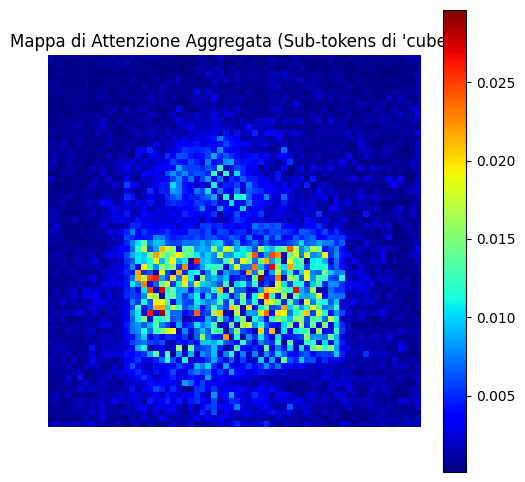

In [3]:
target_obj = "cube"
agg_attn = extract_subtokens_attention(tokenizer, prompt_text, target_obj, attn_mean)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im = ax.imshow(agg_attn.view(64, 64).numpy(), cmap='jet')
plt.colorbar(im)
ax.set_title(f"Mappa di Attenzione Aggregata (Sub-tokens di '{target_obj}')")
ax.axis('off')
plt.show()

## 3. Spectral Co-Embedding e Vettore di Fiedler
Il cuore dell'innovazione: costruiamo il Laplaciano del grafo ibrido e calcoliamo il secondo autovettore.

In [4]:
print("Costruzione del grafo ibrido (Attenzione + Cosine Similarity)...")
L_norm = build_co_embedding_laplacian(agg_attn, v0_flat, alpha_weight=0.6)

print("Calcolo del Vettore di Fiedler...")
eigenvalues, eigenvectors = eigsh(L_norm, k=2, which='SM')
fiedler_vector = eigenvectors[:, 1]

plt.figure(figsize=(8, 6))
plt.imshow(fiedler_vector.reshape(64, 64), cmap='coolwarm')
plt.colorbar()
plt.title("Vettore di Fiedler (Partizionamento Spettrale)")
plt.axis('off')
plt.show()

Costruzione del grafo ibrido (Attenzione + Cosine Similarity)...
Building Attention Graph...
Building Velocity Cosine Graph...
Fusing Graphs...
Calcolo del Vettore di Fiedler...


ArpackNoConvergence: ARPACK error -1: No convergence (40961 iterations, 0/2 eigenvectors converged)

## 4. Risultato Finale: Estrazione Asset
La maschera finale $\alpha$ isola l'oggetto. Vediamo l'effetto sul campo di velocità $v_0$.

In [ ]:
# Determinazione del segno della maschera
mask_pos = (fiedler_vector > 0)
mask_neg = (fiedler_vector <= 0)
final_mask = mask_pos if agg_attn[mask_pos].mean() > agg_attn[mask_neg].mean() else mask_neg

alpha = final_mask.reshape(64, 64)
v0_mag = torch.norm(v0_flat, dim=-1).view(64, 64).numpy()
v0_prior_mag = (v0_mag * alpha)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(v0_mag, cmap='inferno')
axes[0].set_title("Energia Totale (v0 Magnitude)")

axes[1].imshow(alpha, cmap='gray')
axes[1].set_title(f"Maschera Estratta (alpha) per '{target_obj}'")

axes[2].imshow(v0_prior_mag, cmap='inferno')
axes[2].set_title("Generative Prior (Masked v0)")

for ax in axes: ax.axis('off')
plt.show()

## 5. Analisi Critica: Perché è meglio del Gating?
Come si vede dal confronto, la maschera estratta non dipende da una soglia globale di energia, ma dalla **coerenza direzionale** del flusso generativo mediata dall'attenzione. Questo permette di isolare l'oggetto anche in zone a bassa energia o in presenza di rumore di fondo che verrebbe catturato da un semplice thresholding.